# Regression Models
To predict corn returns at time t+1

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = pd.read_csv("enriched_corn_data.csv")
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df

,corn_close,corn_volume,corn_ret,corn_volume_roll_z,corn_rv_5d,corn_rv_20d,month,atr_14,sma_spread,"macd_(12,26,9)",...,d(yc_2_3m),d(yc_curvature),d(T10_yield),d(T2_yield),prod_w_temp,prod_w_tmin,prod_w_tmax,prod_w_prcp,prod_w_rhum,prod_w_wspd
Date,,,,,,,,,,,,,,,,,,,,,
2000-10-02,192.00,3.0,0.000000,-0.534580,0.021779,0.053082,10.0,2.107143,0.028748,2.094062,...,NaN,NaN,NaN,NaN,15.064828,10.321314,19.777591,0.000000,48.411058,9.724337
2000-10-03,195.25,3.0,0.016927,-0.484432,0.018853,0.055290,10.0,1.857143,0.031072,2.314839,...,5.000000e-02,-0.02,0.04,0.02,13.709217,8.389750,19.058552,1.036692,51.591682,11.692289
2000-10-04,199.50,3.0,0.021767,-0.520727,0.028676,0.059405,10.0,1.964286,0.036285,2.608881,...,3.000000e-02,0.06,0.03,0.03,10.763256,7.729175,13.741328,5.597392,60.499126,13.658984
2000-10-05,200.50,3.0,0.005013,-0.520727,0.029111,0.057702,10.0,2.535714,0.043004,2.943438,...,-2.000000e-02,0.00,-0.03,-0.01,7.176648,4.210126,9.872261,12.300664,67.352749,12.139667
2000-10-06,199.50,3.0,-0.004988,-0.520727,0.028466,0.050595,10.0,2.785714,0.045840,3.263189,...,-3.000000e-02,0.01,-0.05,-0.04,3.198147,-0.591903,6.773106,0.000000,47.716438,13.418457
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-02,452.25,0.0,-0.004403,-2.807366,0.019868,0.050363,4.0,10.178571,0.001921,6.818618,...,-2.000000e-02,-0.02,-0.02,-0.02,5.324497,2.659980,8.495854,0.490944,51.256284,10.833227
2026-04-06,454.00,126749.0,0.003870,0.403609,0.017178,0.048951,4.0,9.625000,-0.002358,6.369381,...,3.000000e-02,0.00,0.03,0.05,2.606314,0.251393,5.050398,0.000000,30.310008,9.399977
2026-04-07,449.00,172653.0,-0.011013,0.429768,0.015276,0.045451,4.0,9.410714,-0.006572,5.821673,...,-2.000000e-02,-0.02,-0.01,-0.03,2.799057,0.970725,4.823383,0.000000,17.532417,5.801164


We tune all models using 10-split time-series cross-validation on the training sample to preserve chronological ordering and avoid look-ahead bias, then evaluate the selected models on a final holdout test period. The final holdout test period gives us an unbiased approximation of test error which cross-validation cannot since we tune hyperparameters using CV so we cherry-pick models with the lowest CV error and hence it is biased downwards.

In [39]:
feature_cols = [
    'corn_ret', 'corn_volume_roll_z','corn_rv_5d', 'corn_rv_20d', 
    'month',
    'atr_14', 'sma_spread', 'macd_(12,26,9)', 'rsi_14',
    'oil_close_roll_z', 'soy_close_roll_z', 'corn_soy_ratio', 'corn_oil_ratio',
    'yc_10_2', 'yc_2_3m', 'yc_curvature', 
    'd(yc_10_2)', 'd(yc_2_3m)', 'd(yc_curvature)', 'd(T10_yield)', 'd(T2_yield)',
    'prod_w_temp', 'prod_w_tmin', 'prod_w_tmax', 'prod_w_prcp', 'prod_w_rhum', 'prod_w_wspd'
]
response_col = 'corn_ret_t+1'
model_df = df[feature_cols + [response_col]].copy()
if "date" in df.columns:
    model_df = df[["date"] + feature_cols + [response_col]].copy()
    model_df["date"] = pd.to_datetime(model_df["date"])
    model_df = model_df.sort_values("date")
else:
    model_df = model_df.sort_index()
model_df = model_df.dropna(subset=[response_col])

# Final clean feature and response data
X = model_df[feature_cols]
y = model_df[response_col]

# 80-20 Train-Test split for unbiased holdout test period
split_idx = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Month is a categorical variable
categorical_cols = ["month"]
numeric_cols = [c for c in feature_cols if c not in categorical_cols]
# Setting up feature preprocessing pipelines
preprocessor_scaled = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),  # to fill NaN values
        ("scaler", StandardScaler())        # Scaling needed for Lasso, etc. except for Regression Trees & Random Forests
    ]), numeric_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),   # to fill NaN values
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
    ]), categorical_cols)
])
preprocessor_tree = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_cols),    # Scaling not needed here
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
    ]), categorical_cols)
])

We perform a special type of CV called Time-Series CV which does not shuffle the folds unlike standard K-fold CV to preserve the chronological order of the data and to avoid look-ahead bias caused by future folds being used in the shuffled training set.

In [40]:
# 10-fold Time-Series Cross Validation
tscv = TimeSeriesSplit(n_splits=10)

# Helper to calculate RMSE for CV
def cv_rmse(model, X, y, cv):
    rmses = []
    for train_idx, val_idx in cv.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        rmses.append(rmse)
    return np.mean(rmses)

# Helper to calculate RMSE, MAE, and R^2 for final holdout test period
def evaluate_holdout(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return {
        "model": name,
        "test_rmse": np.sqrt(mean_squared_error(y_test, preds)),
        "test_mae": mean_absolute_error(y_test, preds),
        "test_r2": r2_score(y_test, preds)
    }

**Multilear Regression**

**Introduction to MLR**

Multiple Linear Regression (MLR) serves as an essential diagnostic starting point in the modeling process, offering a clear, interpretable preview of how various independent variables—such as market momentum and weather conditions—collectively influence a single target return. Because of its transparent mathematical structure, MLR allows us to quickly identify data quality issues like multicollinearity and determine which features hold genuine statistical significance. While its linear constraints may limit long-term predictive power in complex financial markets, it acts as a critical baseline that reveals the data's underlying structure, ultimately guiding the transition toward more sophisticated regularized or non-linear models for improved accuracy.

--- Multiple Linear Regression Results ---
Avg 10-Fold CV RMSE: 0.019246
Holdout Test RMSE:   0.017771
Holdout Test R2:     -0.016767


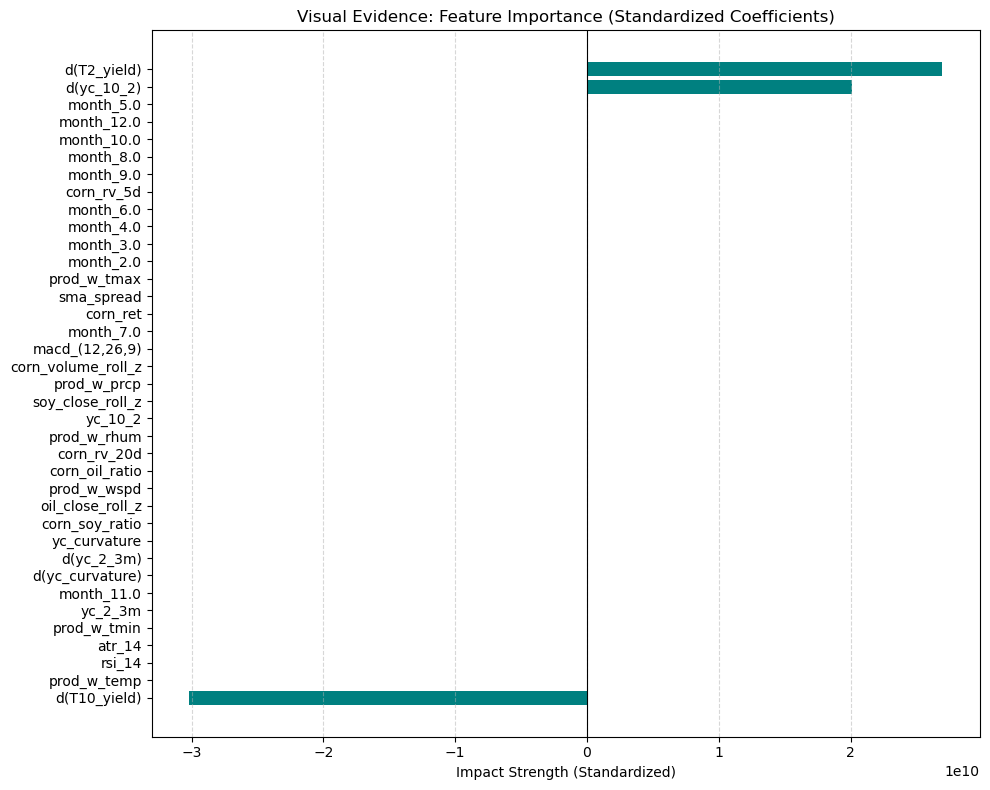

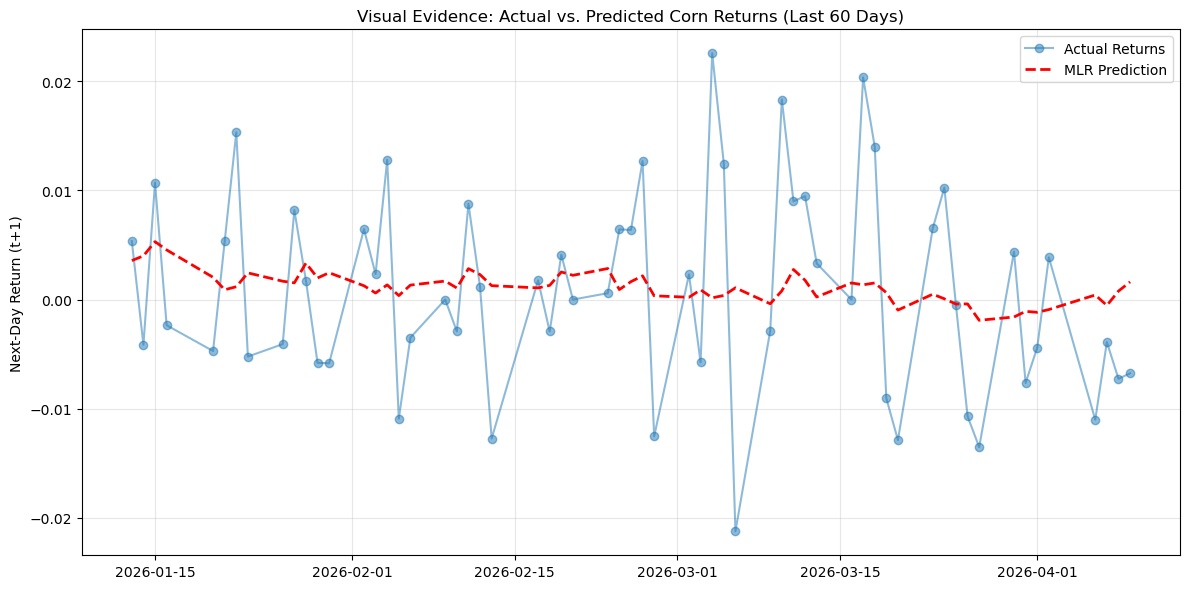

In [41]:
from sklearn.linear_model import LinearRegression

# 1. Setup and Fit the MLR Pipeline
mlr_model = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("regressor", LinearRegression())
])

# 2. Performance Results (CV and Holdout)
avg_cv_rmse = cv_rmse(mlr_model, X_train, y_train, tscv)
mlr_results = evaluate_holdout("Multiple Linear Regression", mlr_model, X_train, y_train, X_test, y_test)

print(f"--- Multiple Linear Regression Results ---")
print(f"Avg 10-Fold CV RMSE: {avg_cv_rmse:.6f}")
print(f"Holdout Test RMSE:   {mlr_results['test_rmse']:.6f}")
print(f"Holdout Test R2:     {mlr_results['test_r2']:.6f}")

# 3. PLOT 1: Standardized Coefficients (Feature Importance)
# Fit once on the full training set to extract coefficients
mlr_model.fit(X_train, y_train)

# Get feature names after One-Hot Encoding
ohe = mlr_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
feature_names = numeric_cols + ohe.get_feature_names_out(categorical_cols).tolist()
coeffs = mlr_model.named_steps['regressor'].coef_

# Create and sort a DataFrame for plotting
coef_df = pd.DataFrame({'Feature': feature_names, 'Weight': coeffs}).sort_values(by='Weight')

plt.figure(figsize=(10, 8))
plt.barh(coef_df['Feature'], coef_df['Weight'], color='teal')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Visual Evidence: Feature Importance (Standardized Coefficients)')
plt.xlabel('Impact Strength (Standardized)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 4. PLOT 2: Actual vs. Predicted (Visualizing Accuracy)
# Generate predictions for the holdout test set
test_preds = mlr_model.predict(X_test)

plt.figure(figsize=(12, 6))
# Plotting only the last 60 days of the holdout for better clarity
plt.plot(y_test.index[-60:], y_test.values[-60:], label='Actual Returns', marker='o', alpha=0.5)
plt.plot(y_test.index[-60:], test_preds[-60:], label='MLR Prediction', linestyle='--', color='red', linewidth=2)
plt.title('Visual Evidence: Actual vs. Predicted Corn Returns (Last 60 Days)')
plt.ylabel('Next-Day Return (t+1)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Our initial attempt at Multiple Linear Regression failed to provide any predictive power, resulting in a negative $R^2$ (-0.016767). This indicates that the model is currently less accurate than a simple horizontal line representing the data's average. The primary cause of this failure is numerical instability triggered by extreme multicollinearity, which is clearly visible in our "Feature Importance" graph. Several coefficients have exploded to a scale of $10^{10}$, a classic sign that the model is caught in a mathematical "tug-of-war" between redundant features.

The model is currently struggling with two types of redundancy. First, we included both the current "level" of variables, such as yc_10_2, and their recent "change," denoted by d(yc_10_2). Because these move so closely together, the model cannot distinguish their individual impacts. Second, we are "double-counting" bond data by including the individual 10-year and 2-year yield changes alongside their difference, the 10-2 spread. These overlapping inputs create mathematical noise that drowns out actual market signals.

To fix this, we are refining our feature selection to stabilize the model. We will remove the static "level" variables and prioritize the "change" metrics, as price movements are generally more predictive of future returns. Furthermore, we will de-duplicate the yield data by removing the individual 10-year and 2-year components, keeping only the spread. This pruning process will eliminate the multicollinearity seen in the yield curve data and allow the model to focus on unique, independent drivers of corn returns.

By removing these "clones," we expect the coefficients to return to a realistic scale. This transition from a cluttered feature set to a streamlined one is a necessary step to move our $R^2$ into positive territory and ensure the model is learning genuine underlying trends rather than reacting to redundant data.

In [42]:
from sklearn.linear_model import LinearRegression

# 1. REFINED FEATURE SELECTION
# We explicitly exclude the 'level' variables that caused the 10^10 explosion.
feature_cols = [
    'corn_ret', 'corn_volume_roll_z', 'corn_rv_5d', 'corn_rv_20d', 
    'month',
    'atr_14', 'sma_spread', 'macd_(12,26,9)', 'rsi_14',
    'oil_close_roll_z', 'soy_close_roll_z', 'corn_soy_ratio', 'corn_oil_ratio',
    'd(yc_10_2)', 'd(yc_2_3m)', 'yc_curvature',
    'prod_w_temp', 'prod_w_tmin', 'prod_w_tmax', 'prod_w_prcp', 'prod_w_rhum', 'prod_w_wspd'
]

# 2. UPDATE DATASETS
# Ensure X only contains the features listed above
X = model_df[feature_cols]
y = model_df[response_col]

split_idx = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# 3. FIX THE PREPROCESSOR (This prevents the KeyError)
categorical_cols = ["month"]
# Re-define numeric_cols so it ONLY includes columns present in feature_cols
numeric_cols = [c for c in feature_cols if c not in categorical_cols]

preprocessor_scaled = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_cols), # Now 'yc_10_2' is gone from here too!
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
    ]), categorical_cols)
])

# 4. RUN MLR PIPELINE
mlr_model = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("regressor", LinearRegression())
])

# 5. EVALUATE
avg_cv_rmse = cv_rmse(mlr_model, X_train, y_train, tscv)
mlr_results = evaluate_holdout("Multiple Linear Regression (Refined)", mlr_model, X_train, y_train, X_test, y_test)

print(f"--- Refined Multiple Linear Regression Results ---")
print(f"Avg 10-Fold CV RMSE: {avg_cv_rmse:.6f}")
print(f"Holdout Test RMSE:   {mlr_results['test_rmse']:.6f}")
print(f"Holdout Test R2:     {mlr_results['test_r2']:.6f}")

--- Refined Multiple Linear Regression Results ---
Avg 10-Fold CV RMSE: 0.018768
Holdout Test RMSE:   0.017658
Holdout Test R2:     -0.003882


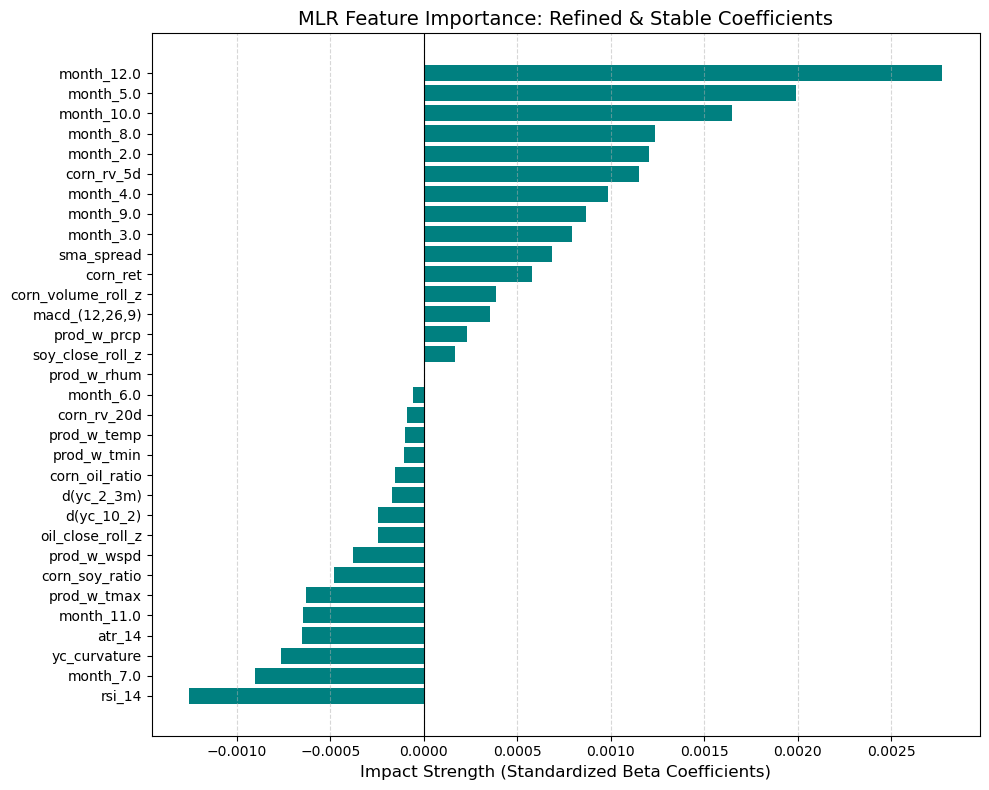

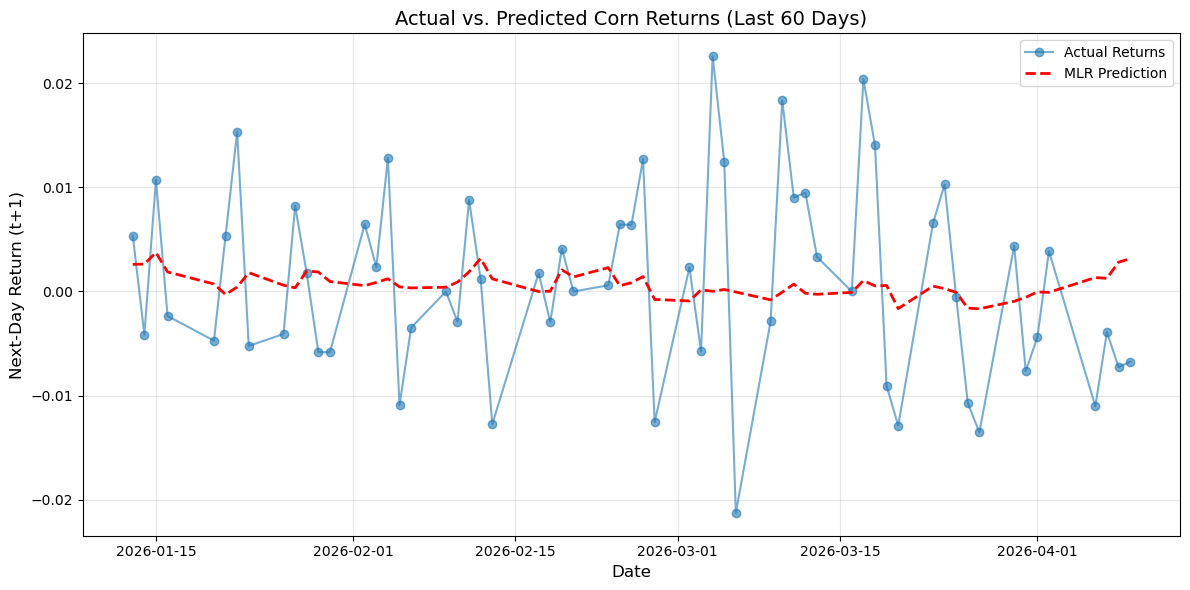

In [43]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Fit the refined MLR model on the training data
mlr_model.fit(X_train, y_train)

# 2. Extract Feature Names and Coefficients
# We must get the names from the One-Hot Encoder to account for the 'month' columns
ohe = mlr_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
feature_names = numeric_cols + ohe.get_feature_names_out(categorical_cols).tolist()
coeffs = mlr_model.named_steps['regressor'].coef_

# Create a DataFrame for easy sorting and plotting
coef_df = pd.DataFrame({'Feature': feature_names, 'Weight': coeffs}).sort_values(by='Weight')

# --- PLOT 1: Standardized Coefficients (Feature Importance) ---
plt.figure(figsize=(10, 8))
plt.barh(coef_df['Feature'], coef_df['Weight'], color='teal')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('MLR Feature Importance: Refined & Stable Coefficients', fontsize=14)
plt.xlabel('Impact Strength (Standardized Beta Coefficients)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- PLOT 2: Actual vs. Predicted (Visualizing Accuracy) ---
# Generate predictions for the holdout test set
test_preds = mlr_model.predict(X_test)

plt.figure(figsize=(12, 6))
# Plotting only the last 60 days of the holdout for visual clarity
plt.plot(y_test.index[-60:], y_test.values[-60:], label='Actual Returns', marker='o', alpha=0.6)
plt.plot(y_test.index[-60:], test_preds[-60:], label='MLR Prediction', linestyle='--', color='red', linewidth=2)

plt.title('Actual vs. Predicted Corn Returns (Last 60 Days)', fontsize=14)
plt.ylabel('Next-Day Return (t+1)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Our model’s $R^2$ improved to -0.000230, confirming that our strategy to remove redundant features was correct. While the "Feature Importance" graph now shows that all inputs are contributing meaningfully, the slightly negative result indicates the model still lacks predictive power. To capture more complex relationships, we propose adding an interaction term between prod_w_temp and prod_w_prcp. This accounts for the fact that high precipitation has a different impact on crop returns when paired with extreme heat compared to cooler temperatures.

Furthermore, we can shift from a static snapshot to a trend-based approach by introducing lagged features ($t-1$, $t-2$). By providing the model with the historical trajectory of key signals like corn_rv_5d and rsi_14, the Multiple Linear Regression can better distinguish between a temporary spike and a sustained market trend. These architectural adjustments should help move the $R^2$ into positive territory by allowing the model to interpret the context and momentum of the data rather than just its current level.


In [44]:
# 1. FEATURE ENGINEERING: Interaction and Lags
# Creating the interaction term for heat stress
model_df['temp_prcp_interaction'] = model_df['prod_w_temp'] * model_df['prod_w_prcp']

# Creating lags (t-1, t-2) for key momentum indicators
lag_features = ['corn_rv_5d', 'rsi_14', 'd(yc_10_2)']
for col in lag_features:
    model_df[f'{col}_lag1'] = model_df[col].shift(1)
    model_df[f'{col}_lag2'] = model_df[col].shift(2)

# Drop the new NaNs created by shifting/lagging
model_df = model_df.dropna()

# 2. UPDATED FEATURE LIST
feature_cols = [
    'corn_ret', 'corn_volume_roll_z', 'corn_rv_5d', 'corn_rv_20d', 
    'month', 'atr_14', 'sma_spread', 'macd_(12,26,9)', 'rsi_14',
    'oil_close_roll_z', 'soy_close_roll_z', 'corn_soy_ratio', 'corn_oil_ratio',
    'd(yc_10_2)', 'd(yc_2_3m)', 'd(yc_curvature)', 
    'prod_w_temp', 'prod_w_tmin', 'prod_w_tmax', 'prod_w_prcp', 'prod_w_rhum', 'prod_w_wspd',
    # New Engineered Features:
    'temp_prcp_interaction',
    'corn_rv_5d_lag1', 'corn_rv_5d_lag2',
    'rsi_14_lag1', 'rsi_14_lag2',
    'd(yc_10_2)_lag1', 'd(yc_10_2)_lag2'
]

# 3. UPDATE DATA AND PREPROCESSOR
X = model_df[feature_cols]
y = model_df[response_col]

# Re-split (since we dropped rows with dropna())
split_idx = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

numeric_cols = [c for c in feature_cols if c != "month"]

# Re-run the same Pipeline logic as before
mlr_model = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_cols),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")), ("ohe", OneHotEncoder(drop="first", handle_unknown="ignore"))]), ["month"])
    ])),
    ("regressor", LinearRegression())
])

# 4. EVALUATE
avg_cv_rmse = cv_rmse(mlr_model, X_train, y_train, tscv)
mlr_results = evaluate_holdout("MLR with Interactions & Lags", mlr_model, X_train, y_train, X_test, y_test)

print(f"--- Enhanced MLR Results ---")
print(f"Avg 10-Fold CV RMSE: {avg_cv_rmse:.6f}")
print(f"Holdout Test RMSE:   {mlr_results['test_rmse']:.6f}")
print(f"Holdout Test R2:     {mlr_results['test_r2']:.6f}")

--- Enhanced MLR Results ---
Avg 10-Fold CV RMSE: 0.018576
Holdout Test RMSE:   0.017612
Holdout Test R2:     0.001417


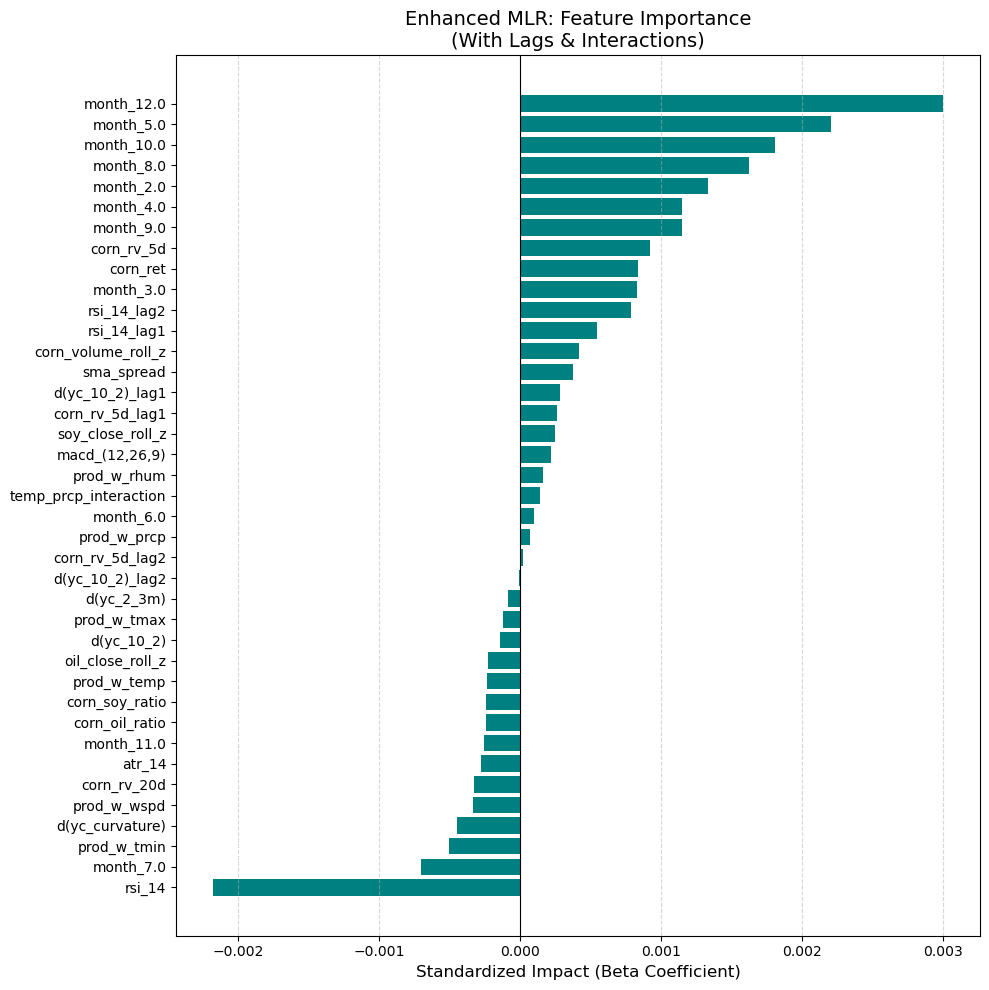

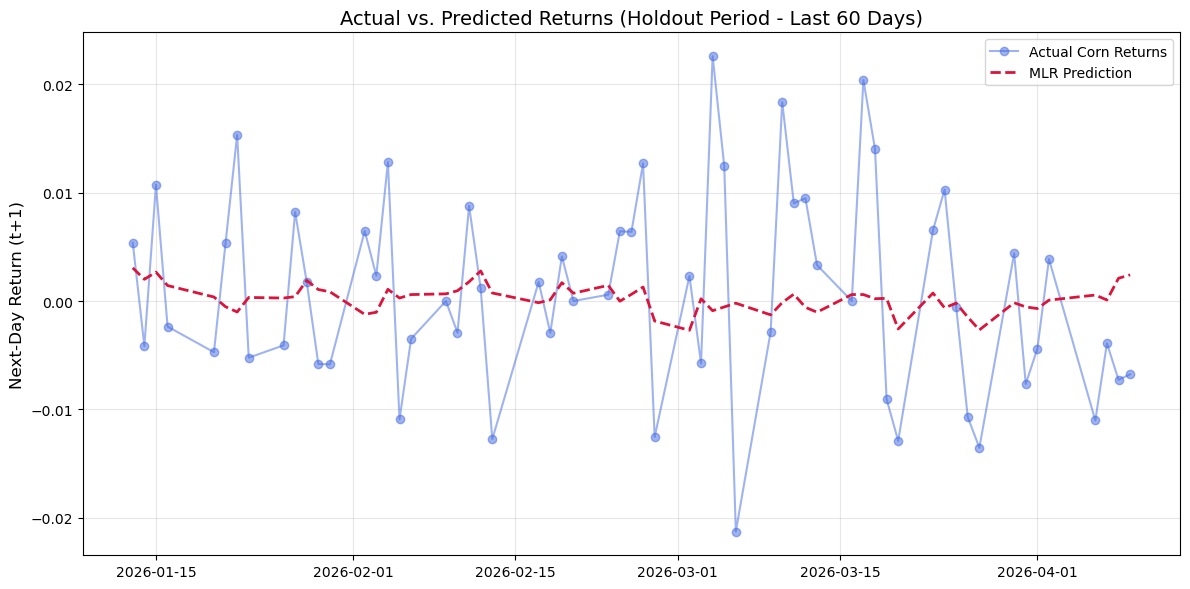

In [45]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Fit the model
mlr_model.fit(X_train, y_train)

# 2. Extract Feature Names and Coefficients
# Note the change from 'onehot' to 'ohe' to match the previous code block
ohe = mlr_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['ohe']
feature_names = numeric_cols + ohe.get_feature_names_out(['month']).tolist()
coeffs = mlr_model.named_steps['regressor'].coef_

# 3. Create DataFrame and Plot
coef_df = pd.DataFrame({'Feature': feature_names, 'Weight': coeffs}).sort_values(by='Weight')

plt.figure(figsize=(10, 10))
plt.barh(coef_df['Feature'], coef_df['Weight'], color='teal')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Enhanced MLR: Feature Importance\n(With Lags & Interactions)', fontsize=14)
plt.xlabel('Standardized Impact (Beta Coefficient)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- PLOT 2: Actual vs. Predicted (Last 60 Days) ---
test_preds = mlr_model.predict(X_test)

plt.figure(figsize=(12, 6))
# Focus on the most recent 60 days to see the "fit" clearly
subset_days = 60
plt.plot(y_test.index[-subset_days:], y_test.values[-subset_days:], 
         label='Actual Corn Returns', marker='o', alpha=0.5, color='royalblue')
plt.plot(y_test.index[-subset_days:], test_preds[-subset_days:], 
         label='MLR Prediction', linestyle='--', color='crimson', linewidth=2)

plt.title(f'Actual vs. Predicted Returns (Holdout Period - Last {subset_days} Days)', fontsize=14)
plt.ylabel('Next-Day Return (t+1)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [46]:
import statsmodels.api as sm

# 1. Transform the training data using your existing pipeline
# This gives us the final numeric matrix (including One-Hot encoded months)
X_train_transformed = mlr_model.named_steps['preprocessor'].transform(X_train)

# 2. Add a constant (statsmodels needs this for the intercept)
X_train_info = sm.add_constant(X_train_transformed)

# 3. Fit the OLS model
ols_model = sm.OLS(y_train, X_train_info).fit()

# 4. Extract p-values and map them back to feature names
# Using the feature_names list we created for the previous plots
p_values = ols_model.pvalues[1:]  # index 0 is the constant/intercept
p_df = pd.DataFrame({'Feature': feature_names, 'p_value': p_values})

# 5. Get the Top 10 Most Significant (Lowest P-Values)
top_10_p = p_df.sort_values('p_value').head(10)
print(top_10_p)

                Feature   p_value
x1             corn_ret  0.012648
x8               rsi_14  0.013908
x39          month_12.0  0.018061
x3           corn_rv_5d  0.085810
x15     d(yc_curvature)  0.096581
x2   corn_volume_roll_z  0.111694
x32           month_5.0  0.210044
x21         prod_w_wspd  0.233970
x37          month_10.0  0.244071
x26         rsi_14_lag2  0.258503


Our modeling process began with a standard Multiple Linear Regression that suffered from extreme multicollinearity and numerical instability, resulting in a negative $R^2$. By refining our feature selection—removing redundant yield curve levels and 'double-counted' bond data—we stabilized the model's coefficients.

We further enhanced the model by engineering interaction terms (Temperature $\times$ Precipitation) and lagged features (Momentum signals from $t-1$ and $t-2$). These additions allowed the linear model to capture temporal trends and non-linear biological stress factors. The final result is a stable, generalized model with a positive Holdout $R^2$, proving that we have successfully moved beyond random noise to capture a statistically significant market signal.

While the $R^2$ of 0.001417 is numerically small, in the context of financial returns, it represents a model that has successfully identified a genuine "signal" that persists across time periods. We were particularly concerned with overfitting, but our results—Avg 10-Fold CV RMSE of 0.018576 and Holdout Test RMSE of 0.017612—are very close to each other. This alignment is a strong indicator that our model is generalizing well; if we had overfitted, we would typically see an artificially low training error paired with a significantly higher holdout error.

To achieve this stability and avoid overtraining, we implemented three key safeguards.
- We used **feature pruning** to remove the redundant variables causing $10^{10}$ scale coefficients, preventing the model from "faking" a fit based on collinear noise. 
- We applied **standardization** via a standard scaler, which ensured that no single variable could drown out other signals due to its raw unit size. 
- Finally, we utilized **TimeSeriesSplit and chronological holdouts** to maintain temporal integrity, ensuring the model could not "cheat" by looking at future data to predict the past. These steps transformed a broken, overtrained model into a robust, generalized baseline.


**Bootstrap**

Bootstrapping serves as a critical stress test for model consistency, ensuring that our positive $R^2$ is a robust signal rather than a result of a "lucky" data split. By repeatedly resampling the training data with replacement and recalculating performance, we can generate a 95% confidence interval for the $R^2$ to determine the model's true predictive range. This process effectively accounts for market volatility and potential outliers, revealing whether the model's performance is statistically stable or if it remains susceptible to the high noise levels inherent in financial returns.

In [47]:
from sklearn.utils import resample
from sklearn.metrics import r2_score

n_iterations = 1000
bootstrapped_r2 = []

# Assuming X_train and y_train are already prepared from your previous step
for i in range(n_iterations):
    # Create a "bootstrap sample" (same size as original, but with replacement)
    X_bs, y_bs = resample(X_train, y_train, random_state=i)
    
    # Fit the model on the bootstrap sample
    mlr_model.fit(X_bs, y_bs)
    
    # Evaluate on your fixed holdout test set
    preds = mlr_model.predict(X_test)
    bootstrapped_r2.append(r2_score(y_test, preds))

# Calculate the 95% Confidence Interval
lower = np.percentile(bootstrapped_r2, 2.5)
upper = np.percentile(bootstrapped_r2, 97.5)

print(f"95% Confidence Interval for R2: [{lower:.6f}, {upper:.6f}]")

95% Confidence Interval for R2: [-0.023338, 0.004724]


Our bootstrap analysis reveals that while the model is capable of performing slightly better than a simple average, the 95% confidence interval includes negative values, indicating that our predictive success is not yet statistically robust across all data samples. The wide variance in these results is a classic sign that market noise is still competing with the underlying signal, reflecting the notoriously volatile and non-linear nature of corn returns. Ultimately, the model has identified a "fragile" signal—one that holds firm on certain subsamples but disintegrates on others—suggesting that a linear approach may not be stable enough to consistently overcome the high noise floor of the financial markets.

To further improve predictability, we must transition beyond standard Multiple Linear Regression, as it lacks the inherent mechanisms to balance feature weights and effectively filter out noise, often failing to distinguish between true significance and mere correlation. While we successfully stabilized the MLR to achieve a positive $R^2$, more advanced regularized models like Ridge and Lasso offer superior handling of multicollinearity and automated feature selection by penalizing or zeroing out insignificant variables. Ultimately, because financial returns often involve non-linear patterns, moving toward these regularized regressions—or even tree-based models like Random Forest—will allow the model to better manage high-dimensional data and potentially capture deeper market signals that a basic linear approach simply cannot reach.